In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "/data/anantaraha/amp/dataset/laion_art/output/exp3/exp3_image_scores.csv"

df = pd.read_csv(CSV_PATH)

metrics = ["A_MD", "A_DD", "S_gap"]
condition_order = ["source", "adversarial", "target"]

print(f"Rows: {len(df)}")
print(df["condition"].value_counts())

Rows: 150
source         50
adversarial    50
target         50
Name: condition, dtype: int64


In [3]:
summary = (
    df.groupby("condition")[metrics]
      .agg(["mean", "median", "std"])
      .reindex(condition_order)
)

# Make it compact
summary.columns = [f"{metric}_{stat}" for metric, stat in summary.columns]
summary = summary.round(4)

display(summary)

,A_MD_mean,A_MD_median,A_MD_std,A_DD_mean,A_DD_median,A_DD_std,S_gap_mean,S_gap_median,S_gap_std
condition,,,,,,,,,
source,0.5215,0.5231,0.0241,0.7135,0.7127,0.0219,0.1920,0.1999,0.0235
adversarial,0.4509,0.4379,0.0710,0.8308,0.8565,0.0908,0.3799,0.3882,0.0791
target,0.5231,0.5209,0.0223,0.7224,0.7171,0.0297,0.1993,0.2045,0.0222


In [4]:
mean_table = (
    df.groupby("condition")[metrics]
      .mean()
      .reindex(condition_order)
      .round(4)
)

display(mean_table)

,A_MD,A_DD,S_gap
condition,,,
source,0.5215,0.7135,0.1920
adversarial,0.4509,0.8308,0.3799
target,0.5231,0.7224,0.1993


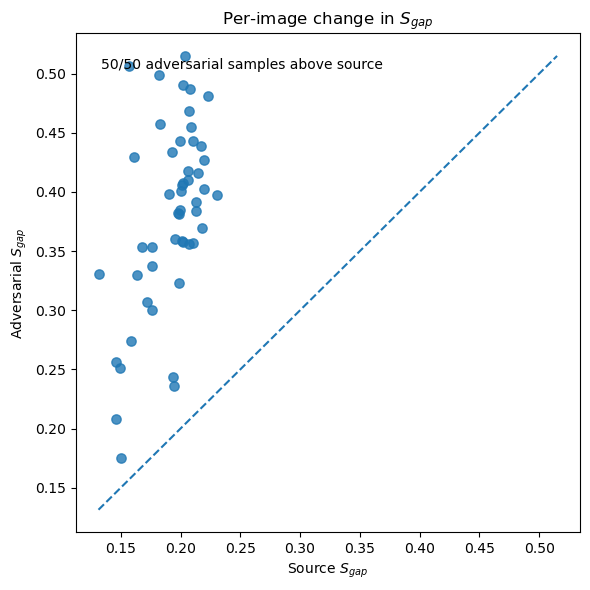

In [5]:
paired = (
    df.pivot(index="sample_id", columns="condition", values="S_gap")
      .dropna(subset=["source", "adversarial"])
)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(paired["source"], paired["adversarial"], s=45, alpha=0.8)

low = min(paired["source"].min(), paired["adversarial"].min())
high = max(paired["source"].max(), paired["adversarial"].max())

ax.plot([low, high], [low, high], "--", linewidth=1.5)

ax.set_xlabel(r"Source $S_{gap}$")
ax.set_ylabel(r"Adversarial $S_{gap}$")
ax.set_title(r"Per-image change in $S_{gap}$")

n_above = (paired["adversarial"] > paired["source"]).sum()
ax.text(
    0.05, 0.95,
    f"{n_above}/{len(paired)} adversarial samples above source",
    transform=ax.transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

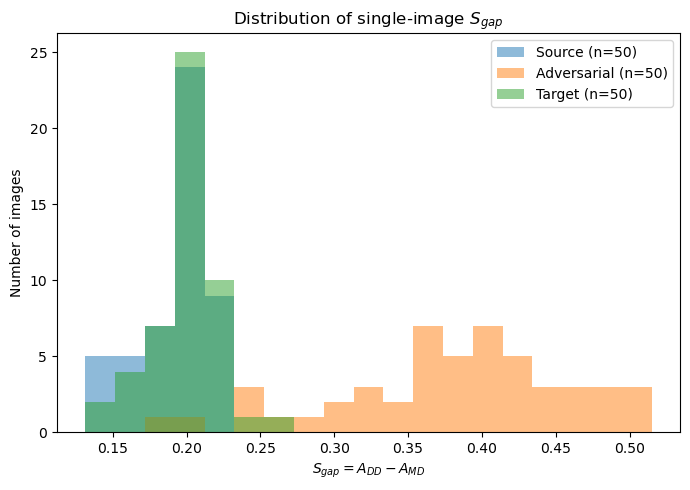

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

all_scores = df["S_gap"].dropna()
bins = np.linspace(all_scores.min(), all_scores.max(), 20)

for condition in condition_order:
    values = df.loc[df["condition"] == condition, "S_gap"].dropna()
    ax.hist(
        values,
        bins=bins,
        alpha=0.5,
        label=f"{condition.capitalize()} (n={len(values)})"
    )

ax.set_xlabel(r"$S_{gap} = A_{DD} - A_{MD}$")
ax.set_ylabel("Number of images")
ax.set_title(r"Distribution of single-image $S_{gap}$")
ax.legend()

plt.tight_layout()
plt.show()